<a href="https://colab.research.google.com/github/4553kietgroup-cloud/GOOGLE-PAGE-RANK-MINI/blob/main/Back_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================
# CELL 1: IMPORTS
# ============================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
# ============================================
# CELL 2: PROJECT INPUTS
# ============================================

# Five web pages
pages = ["A", "B", "C", "D", "E"]

# Benchmark web graph
#
# A -> B, C
# B -> C
# C -> A, D
# D -> C, E
# E -> A
#
# Each tuple means:
# (source_page, destination_page)

links = [
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("C", "A"),
    ("C", "D"),
    ("D", "C"),
    ("D", "E"),
    ("E", "A")
]

# Standard PageRank damping factor
damping = 0.85

# Initial PageRank vector
# Start with equal probability for every page
initial_rank = np.ones(len(pages)) / len(pages)

# Power iteration settings
max_iterations = 100
tolerance = 1e-10

print("Pages :", pages)
print("Links :", links)
print("Damping factor :", damping)

Pages : ['A', 'B', 'C', 'D', 'E']
Links : [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('C', 'D'), ('D', 'C'), ('D', 'E'), ('E', 'A')]
Damping factor : 0.85


In [9]:
# ============================================
# CELL 3: BUILD LINK MATRIX
# ============================================

n = len(pages)

# Create an n x n zero matrix
# Rows = destination pages
# Columns = source pages
link_matrix = np.zeros((n, n))

# Map page names to matrix indices
page_index = {page: i for i, page in enumerate(pages)}

# Fill the matrix
for source, destination in links:
    i = page_index[destination]
    j = page_index[source]

    link_matrix[i, j] = 1

print("LINK / ADJACENCY MATRIX")
print("========================")
print(link_matrix)

print("\nRows    = destination pages")
print("Columns = source pages")

LINK / ADJACENCY MATRIX
[[0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]

Rows    = destination pages
Columns = source pages


In [10]:
# ============================================
# CELL 4: TRANSITION MATRIX
# ============================================

transition_matrix = np.zeros((n, n))

for j in range(n):

    # Number of outgoing links from page j
    outgoing_links = np.sum(link_matrix[:, j])

    if outgoing_links == 0:
        # Dangling page assumption:
        # distribute probability equally among all pages
        transition_matrix[:, j] = 1 / n

    else:
        # Divide each outgoing link by total outgoing links
        transition_matrix[:, j] = (
            link_matrix[:, j] / outgoing_links
        )

print("TRANSITION PROBABILITY MATRIX")
print("=============================")
print(transition_matrix)

# Verify that every column sums to 1
print("\nColumn sums:")
print(np.sum(transition_matrix, axis=0))

TRANSITION PROBABILITY MATRIX
[[0.  0.  0.5 0.  1. ]
 [0.5 0.  0.  0.  0. ]
 [0.5 1.  0.  0.5 0. ]
 [0.  0.  0.5 0.  0. ]
 [0.  0.  0.  0.5 0. ]]

Column sums:
[1. 1. 1. 1. 1.]


In [11]:
# ============================================
# CELL 5: GOOGLE / PAGERANK MATRIX
# ============================================

# PageRank uses:
#
# G = dP + (1-d)/n * J
#
# where:
# d = damping factor
# P = transition matrix
# J = matrix containing all ones

J = np.ones((n, n))

google_matrix = (
    damping * transition_matrix
    + ((1 - damping) / n) * J
)

print("GOOGLE MATRIX")
print("=============")
print(google_matrix)

print("\nColumn sums:")
print(np.sum(google_matrix, axis=0))

GOOGLE MATRIX
[[0.03  0.03  0.455 0.03  0.88 ]
 [0.455 0.03  0.03  0.03  0.03 ]
 [0.455 0.88  0.03  0.455 0.03 ]
 [0.03  0.03  0.455 0.03  0.03 ]
 [0.03  0.03  0.03  0.455 0.03 ]]

Column sums:
[1. 1. 1. 1. 1.]


In [12]:
# ============================================
# CELL 6: POWER ITERATION
# ============================================

rank = initial_rank.copy()

# Store every iteration for analysis and charts
history = [rank.copy()]

converged = False

for iteration in range(1, max_iterations + 1):

    # Power method:
    #
    # r(k+1) = G r(k)
    #
    new_rank = google_matrix @ rank

    history.append(new_rank.copy())

    # Check convergence
    error = np.linalg.norm(new_rank - rank, ord=1)

    if error < tolerance:
        rank = new_rank
        converged = True
        break

    rank = new_rank


history = np.array(history)

print("POWER ITERATION RESULT")
print("======================")
print("Iterations:", iteration)
print("Final error:", error)
print("Converged:", converged)

print("\nFinal PageRank vector:")
for page, score in zip(pages, rank):
    print(f"{page} = {score:.10f}")

print("\nSum of PageRank values:")
print(np.sum(rank))

POWER ITERATION RESULT
Iterations: 41
Final error: 6.017658593648889e-11
Converged: True

Final PageRank vector:
A = 0.2574452947
B = 0.1394142503
C = 0.3303327085
D = 0.1703914011
E = 0.1024163455

Sum of PageRank values:
1.0000000000000018


In [13]:
# ============================================
# CELL 7: EIGENVALUE = 1 VERIFICATION
# ============================================

# If rank is the steady-state vector:
#
# G r = r
#
# Comparing with:
#
# G r = lambda r
#
# gives:
#
# lambda = 1

eigenvalues, eigenvectors = np.linalg.eig(google_matrix)

# Find eigenvalue closest to 1
closest_index = np.argmin(np.abs(eigenvalues - 1))

eigenvalue = eigenvalues[closest_index].real

print("EIGENVALUE VERIFICATION")
print("=======================")

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvalue closest to 1:")
print(eigenvalue)

print("\nG × PageRank:")
print(google_matrix @ rank)

print("\nPageRank vector:")
print(rank)

print("\nVerification error:")
print(np.linalg.norm(
    google_matrix @ rank - rank
))

EIGENVALUE VERIFICATION
Eigenvalues:
[ 1.      +0.j        0.080659+0.443354j  0.080659-0.443354j
 -0.505659+0.256191j -0.505659-0.256191j]

Eigenvalue closest to 1:
1.0000000000000016

G × PageRank:
[0.257445 0.139414 0.330333 0.170391 0.102416]

PageRank vector:
[0.257445 0.139414 0.330333 0.170391 0.102416]

Verification error:
1.661447670371406e-11


In [14]:
# ============================================
# CELL 8: SYMBOLIC MATHEMATICS
# ============================================

# Convert Google matrix into a SymPy matrix
G_sym = sp.Matrix(google_matrix)

print("SYMPY GOOGLE MATRIX")
print("===================")
sp.pprint(G_sym)

# Calculate characteristic information
eigen_data = G_sym.eigenvals()

print("\nEIGENVALUES")
print("===========")

for value, multiplicity in eigen_data.items():
    print("Eigenvalue:", value)
    print("Multiplicity:", multiplicity)

SYMPY GOOGLE MATRIX
⎡0.03   0.03  0.455  0.03   0.88⎤
⎢                               ⎥
⎢0.455  0.03  0.03   0.03   0.03⎥
⎢                               ⎥
⎢0.455  0.88  0.03   0.455  0.03⎥
⎢                               ⎥
⎢0.03   0.03  0.455  0.03   0.03⎥
⎢                               ⎥
⎣0.03   0.03  0.03   0.455  0.03⎦

EIGENVALUES
Eigenvalue: 1.0 - 2.78133084518913e-64*I
Multiplicity: 1
Eigenvalue: 0.0806585126334277 - 0.443353614486991*I
Multiplicity: 1
Eigenvalue: -0.505658512633428 - 0.256191138762074*I
Multiplicity: 1
Eigenvalue: -0.505658512633428 + 0.256191138762074*I
Multiplicity: 1
Eigenvalue: 0.0806585126334277 + 0.443353614486991*I
Multiplicity: 1


In [15]:
# ============================================
# CELL 9: RESULTS TABLE
# ============================================

ranking = sorted(
    zip(pages, rank),
    key=lambda x: x[1],
    reverse=True
)

print("FINAL PAGERANK RANKING")
print("======================")

print(f"{'Rank':<8}{'Page':<10}{'PageRank':<15}")
print("-" * 33)

for position, (page, score) in enumerate(ranking, start=1):
    print(
        f"{position:<8}"
        f"{page:<10}"
        f"{score:.10f}"
    )

print("\nMost important page:")
print(f"Page {ranking[0][0]}")

print(f"\nHighest PageRank score:")
print(f"{ranking[0][1]:.10f}")

FINAL PAGERANK RANKING
Rank    Page      PageRank       
---------------------------------
1       C         0.3303327085
2       A         0.2574452947
3       D         0.1703914011
4       B         0.1394142503
5       E         0.1024163455

Most important page:
Page C

Highest PageRank score:
0.3303327085


In [16]:
# ============================================
# CELL 10: CONVERGENCE INFORMATION
# ============================================

print("ITERATION HISTORY")
print("=================")

print(
    f"{'Iteration':<12}"
    + "".join(f"{page:<12}" for page in pages)
)

print("-" * 72)

# Display selected iterations
for i in range(len(history)):

    if i < 10 or i == len(history) - 1:

        print(
            f"{i:<12}"
            + "".join(
                f"{value:<12.6f}"
                for value in history[i]
            )
        )

ITERATION HISTORY
Iteration   A           B           C           D           E           
------------------------------------------------------------------------
0           0.200000    0.200000    0.200000    0.200000    0.200000    
1           0.285000    0.115000    0.370000    0.115000    0.115000    
2           0.285000    0.151125    0.297750    0.187250    0.078875    
3           0.223588    0.151125    0.359163    0.156544    0.109581    
4           0.275788    0.125025    0.320012    0.182644    0.096531    
5           0.248057    0.147210    0.331105    0.166005    0.107624    
6           0.262200    0.135424    0.331105    0.170719    0.100552    
7           0.256189    0.141435    0.329101    0.170719    0.102556    
8           0.257040    0.138880    0.331656    0.169868    0.102556    
9           0.258126    0.139242    0.329484    0.170954    0.102194    
41          0.257445    0.139414    0.330333    0.170391    0.102416    


In [17]:
# ============================================
# CELL 11: PROJECT SUMMARY
# ============================================

print("""
==================================================
             GOOGLE PAGERANK MINI
==================================================

MATHEMATICAL MODEL
------------------

1. Link Matrix
   Represents which pages link to which pages.

2. Transition Matrix P
   Converts links into probabilities.

3. Google Matrix G
   Includes the damping factor.

4. Power Method
   Repeatedly calculates:

       r(k+1) = G r(k)

5. Steady State
   When the vector converges:

       G r = r

6. Eigenvalue Interpretation

       G r = λr

   Therefore:

       λ = 1

==================================================
FINAL RESULT
==================================================
""")

for position, (page, score) in enumerate(ranking, 1):
    print(f"{position}. Page {page} → {score:.6f}")

print("\nMost important page:", ranking[0][0])


             GOOGLE PAGERANK MINI

MATHEMATICAL MODEL
------------------

1. Link Matrix
   Represents which pages link to which pages.

2. Transition Matrix P
   Converts links into probabilities.

3. Google Matrix G
   Includes the damping factor.

4. Power Method
   Repeatedly calculates:

       r(k+1) = G r(k)

5. Steady State
   When the vector converges:

       G r = r

6. Eigenvalue Interpretation

       G r = λr

   Therefore:

       λ = 1

FINAL RESULT

1. Page C → 0.330333
2. Page A → 0.257445
3. Page D → 0.170391
4. Page B → 0.139414
5. Page E → 0.102416

Most important page: C


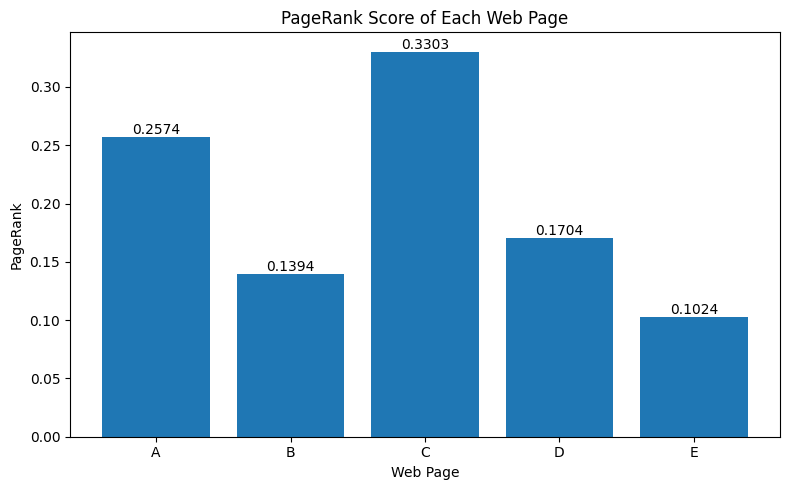

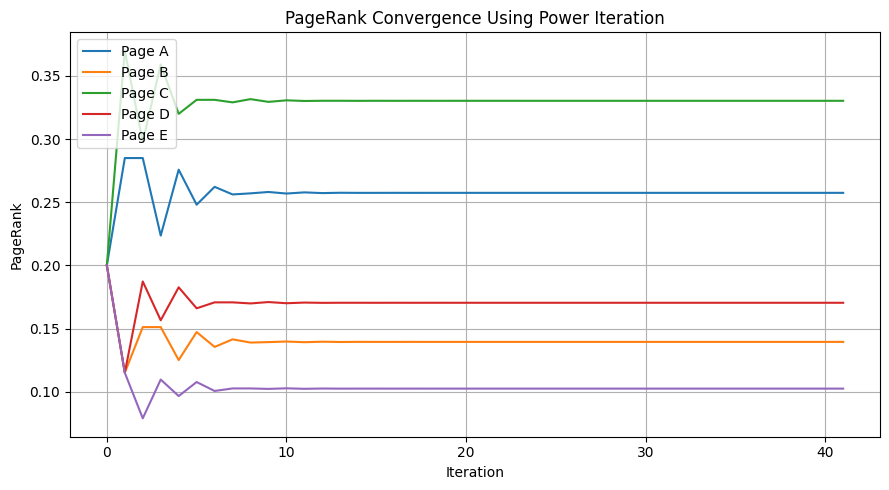

In [18]:
# ============================================
# CELL 12: VISUALIZATION
# ============================================

# ---------- Chart 1: PageRank Scores ----------

plt.figure(figsize=(8, 5))

plt.bar(pages, rank)

plt.title("PageRank Score of Each Web Page")
plt.xlabel("Web Page")
plt.ylabel("PageRank")

for i, score in enumerate(rank):
    plt.text(
        i,
        score,
        f"{score:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ---------- Chart 2: Power Iteration ----------

plt.figure(figsize=(9, 5))

for i, page in enumerate(pages):
    plt.plot(
        history[:, i],
        label=f"Page {page}"
    )

plt.title("PageRank Convergence Using Power Iteration")
plt.xlabel("Iteration")
plt.ylabel("PageRank")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# CELL 13: BENCHMARK TEST
# ============================================

print("BENCHMARK TEST")
print("==============")

# Basic mathematical checks

assert link_matrix.shape == (5, 5)

# Every transition column should sum to 1
assert np.allclose(
    transition_matrix.sum(axis=0),
    1
)

# Google matrix columns should sum to 1
assert np.allclose(
    google_matrix.sum(axis=0),
    1
)

# PageRank values should sum to 1
assert np.isclose(
    rank.sum(),
    1
)

# Steady-state condition
assert np.linalg.norm(
    google_matrix @ rank - rank
) < 1e-8

# Eigenvalue should be approximately 1
assert abs(eigenvalue - 1) < 1e-8

print("✓ Link matrix test passed")
print("✓ Transition matrix test passed")
print("✓ Google matrix test passed")
print("✓ PageRank normalization test passed")
print("✓ Eigenvalue λ = 1 test passed")
print("✓ Power iteration convergence test passed")

print("\nALL BENCHMARK TESTS PASSED ✓")

BENCHMARK TEST
✓ Link matrix test passed
✓ Transition matrix test passed
✓ Google matrix test passed
✓ PageRank normalization test passed
✓ Eigenvalue λ = 1 test passed
✓ Power iteration convergence test passed

ALL BENCHMARK TESTS PASSED ✓
